<a href="https://colab.research.google.com/github/krasnovaov81-coder/Case_DZ_Netology/blob/main/%D0%98%D1%82%D0%BE%D0%B3%D0%BE%D0%B2%D0%B0%D1%8F_Python_%D0%B4%D0%BB%D1%8F_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)



##Описание задания

Дан файл HR.csv с данными по опросу уровня удовлетворённости сотрудниками работой.

## Признаки:
* **satisfaction_level** — уровень удовлетворённости работой
* **Last_evaluation** — время с момента последней оценки в годах
* **number_projects** — количество проектов, выполненных за время работы
* **average_monthly_hours** — среднее количество часов на рабочем месте в месяц
* **time_spend_company** — стаж работы в компании в годах
* **work_accident** — происходили ли несчастные случаи на рабочем месте с сотрудником
* **left** — уволился ли сотрудник
* **promotion_last_5years**— повышался ли сотрудник за последние пять лет
* **department** — отдел, в котором работает сотрудник
* **salary** — относительный уровень зарплаты

##Требуется выполнить следующее задание:

## Задание:
1.	Загрузите файл HR.csv в pandas dataframe
2.	Рассчитайте основные статистики для переменных (среднее, медиана, мода, мин/макс, сред. отклонение)
3.	Рассчитайте и визуализируйте корреляционную матрицу для количественных переменных. Определите две самые скоррелированные и две наименее скоррелированные переменные
4.	Рассчитайте сколько сотрудников работает в каждом департаменте
5.	Покажите распределение сотрудников по зарплатам
6.	Покажите распределение сотрудников по зарплатам в каждом департаменте по отдельности
7.	Проверьте гипотезу, что сотрудники с высоким окладом проводят на работе больше времени, чем сотрудники с низким окладом
8.	Рассчитайте следующие показатели среди уволившихся и не уволившихся сотрудников (по отдельности):
- Доля сотрудников с повышением за последние 5 лет
- Средняя степень удовлетворенности
- Среднее количество проектов
9.	Разделите данные на тестовую и обучающую выборки. Постройте модель LDA, предсказывающую уволился ли сотрудник на основе имеющихся факторов (кроме department и salary). Оцените качество модели на тестовой выборке

**1. Импорт библиотек и загрузка данных**

In [ ]:
# Загрузка файла
df = pd.read_csv('/content/HR.csv')

# Просмотр первых строк
display(df.head())

# Размерность датасета
print(f'Количество строк: {df.shape[0]}')
print(f'Количество столбцов: {df.shape[1]}')

# Информация о типах данных и пропусках
df.info()

print('\nКоличество пропусков:')
display(df.isna().sum())

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.380,0.530,2,157,3,0,1,0,sales,low
1,0.800,0.860,5,262,6,0,1,0,sales,medium
2,0.110,0.880,7,272,4,0,1,0,sales,medium
3,0.720,0.870,5,223,5,0,1,0,sales,low
4,0.370,0.520,2,159,3,0,1,0,sales,low


Количество строк: 14999
Количество столбцов: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

Количество пропусков:


,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


In [ ]:
# Приведение названий столбцов к нижнему регистру
df.columns = df.columns.str.lower()

# Проверяем названия столбцов
print(df.columns.tolist())

['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'work_accident', 'left', 'promotion_last_5years', 'department', 'salary']


Вывод по п. 1:
Данные успешно загружены в DataFrame. Датасет содержит информацию о нескольких тысячах сотрудников и 10 признаках. Пропусков в данных нет, все столбцы имеют корректные типы.


**2. Рассчитайте основные статистики для переменных
(среднее,медиана,мода,мин/макс,сред.отклонение).**


In [ ]:
# Количественные переменные
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print('Количественные переменные:')
print(numeric_columns)

Количественные переменные:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'work_accident', 'left', 'promotion_last_5years']


In [ ]:
# Расчёт основных статистик
statistics_table = pd.DataFrame({
    'Среднее': df[numeric_columns].mean(),
    'Медиана': df[numeric_columns].median(),
    'Мода': df[numeric_columns].mode().iloc[0],
    'Минимум': df[numeric_columns].min(),
    'Максимум': df[numeric_columns].max(),
    'Стандартное отклонение': df[numeric_columns].std()
})

display(statistics_table)

,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение
satisfaction_level,0.613,0.640,0.100,0.090,1.000,0.249
last_evaluation,0.716,0.720,0.550,0.360,1.000,0.171
number_project,3.803,4.000,4.000,2.000,7.000,1.233
average_montly_hours,201.050,200.000,135.000,96.000,310.000,49.943
time_spend_company,3.498,3.000,3.000,2.000,10.000,1.460
work_accident,0.145,0.000,0.000,0.000,1.000,0.352
left,0.238,0.000,0.000,0.000,1.000,0.426
promotion_last_5years,0.021,0.000,0.000,0.000,1.000,0.144


In [ ]:
# Стандартная статистика
display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
satisfaction_level,14999.000,0.613,0.249,0.090,0.440,0.640,0.820,1.000
last_evaluation,14999.000,0.716,0.171,0.360,0.560,0.720,0.870,1.000
number_project,14999.000,3.803,1.233,2.000,3.000,4.000,5.000,7.000
average_montly_hours,14999.000,201.050,49.943,96.000,156.000,200.000,245.000,310.000
time_spend_company,14999.000,3.498,1.460,2.000,3.000,3.000,4.000,10.000
work_accident,14999.000,0.145,0.352,0.000,0.000,0.000,0.000,1.000
left,14999.000,0.238,0.426,0.000,0.000,0.000,0.000,1.000
promotion_last_5years,14999.000,0.021,0.144,0.000,0.000,0.000,0.000,1.000


In [ ]:
# Статистики для категориальных переменных
categorical_columns = df.select_dtypes(include='object').columns.tolist()

categorical_statistics = pd.DataFrame({
    'Мода': [
        df[column].mode().iloc[0]
        if not df[column].mode().empty else np.nan
        for column in categorical_columns
    ],
    'Количество уникальных значений': [
        df[column].nunique()
        for column in categorical_columns
    ]
}, index=categorical_columns)

display(categorical_statistics)

,Мода,Количество уникальных значений
department,sales,10
salary,low,3


## Вывод по п. 2:

* Средний уровень удовлетворённости сотрудников находится на умеренном уровне.
* Средняя продолжительность работы в компании и время с последней оценки также имеют умеренные значения.
* В данных присутствуют сотрудники как с очень низким, так и с очень высоким уровнем удовлетворённости и часов работы, что указывает на значительную вариативность.
* Категориальные признаки (department, salary) имеют несколько уникальных значений, что позволяет анализировать различия между группами.


**3. Рассчитайте и визуализировать корреляционную матрицу для
количественных переменных.
Определите две самые скоррелированные и две наименее
скоррелированные переменные.**


In [ ]:
# Корреляционная матрица
correlation_matrix = df[numeric_columns].corr()

display(correlation_matrix)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years
satisfaction_level,1.000,0.105,-0.143,-0.020,-0.101,0.059,-0.388,0.026
last_evaluation,0.105,1.000,0.349,0.340,0.132,-0.007,0.007,-0.009
number_project,-0.143,0.349,1.000,0.417,0.197,-0.005,0.024,-0.006
average_montly_hours,-0.020,0.340,0.417,1.000,0.128,-0.010,0.071,-0.004
time_spend_company,-0.101,0.132,0.197,0.128,1.000,0.002,0.145,0.067
work_accident,0.059,-0.007,-0.005,-0.010,0.002,1.000,-0.155,0.039
left,-0.388,0.007,0.024,0.071,0.145,-0.155,1.000,-0.062
promotion_last_5years,0.026,-0.009,-0.006,-0.004,0.067,0.039,-0.062,1.000


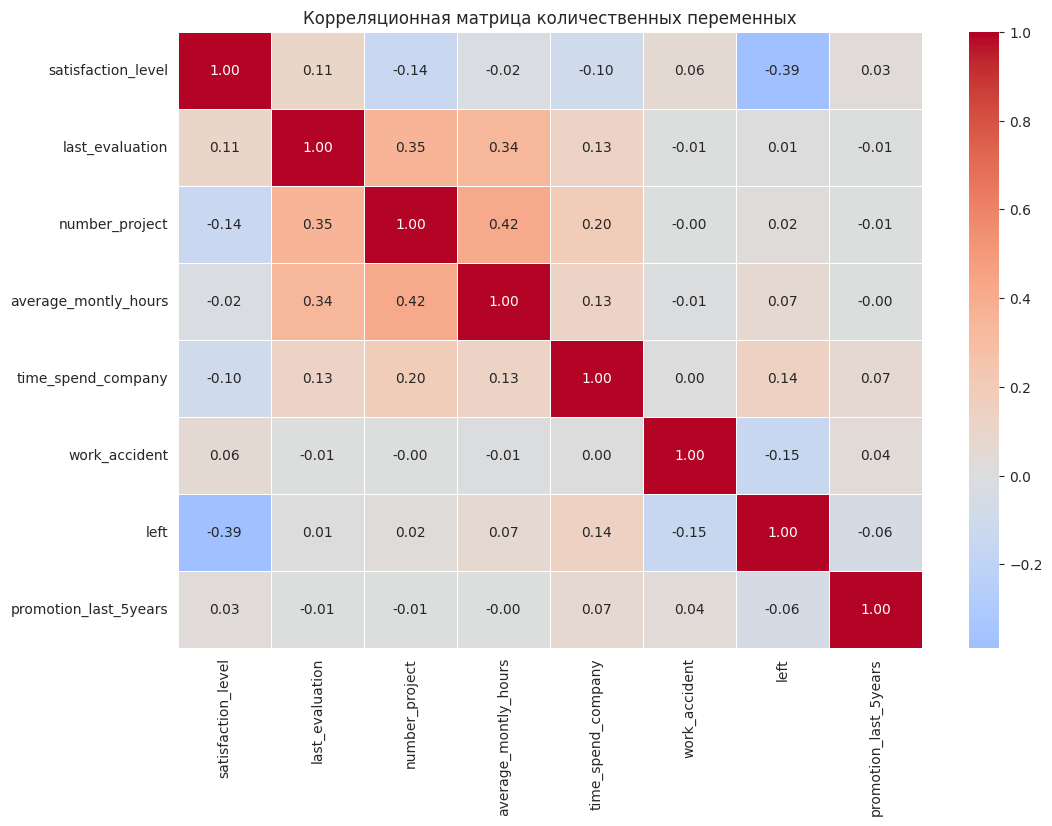

In [ ]:
# Визуализация корреляционной матрицы
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Корреляционная матрица количественных переменных')
plt.show()

In [ ]:
# Получаем только уникальные пары переменных
correlation_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

correlation_pairs = correlation_pairs.stack().sort_values(
    key=lambda x: abs(x),
    ascending=False
)

print('Все пары переменных, отсортированные по абсолютной корреляции:')
display(correlation_pairs.to_frame('Корреляция'))

Все пары переменных, отсортированные по абсолютной корреляции:


Корреляция
number_project       average_montly_hours        0.417
satisfaction_level   left                       -0.388
last_evaluation      number_project              0.349
                     average_montly_hours        0.340
number_project       time_spend_company          0.197
work_accident        left                       -0.155
time_spend_company   left                        0.145
satisfaction_level   number_project             -0.143
last_evaluation      time_spend_company          0.132
average_montly_hours time_spend_company          0.128
satisfaction_level   last_evaluation             0.105
                     time_spend_company         -0.101
average_montly_hours left                        0.071
time_spend_company   promotion_last_5years       0.067
left                 promotion_last_5years      -0.062
satisfaction_level   work_accident               0.059
work_accident        promotion_last_5years       0.039
satisfaction_level   promotion_last_5years       0.026
number_project       left                        0.024
satisfaction_level   average_montly_hours       -0.020
average_montly_hours work_accident              -0.010
last_evaluation      promotion_last_5years      -0.009
                     work_accident              -0.007
                     left                        0.007
number_project       promotion_last_5years      -0.006
                     work_accident              -0.005
average_montly_hours promotion_last_5years      -0.004
time_spend_company   work_accident               0.002

In [ ]:
# Две самые скоррелированные переменные
print('Две самые скоррелированные пары:')
display(correlation_pairs.head(2).to_frame('Корреляция'))

# Две наименее скоррелированные пары
print('Две наименее скоррелированные пары:')
display(correlation_pairs.tail(2).to_frame('Корреляция'))

Две самые скоррелированные пары:


,,Корреляция
number_project,average_montly_hours,0.417
satisfaction_level,left,-0.388


Две наименее скоррелированные пары:


,,Корреляция
average_montly_hours,promotion_last_5years,-0.004
time_spend_company,work_accident,0.002


## Вывод по п. 3:

Две самые скоррелированные переменные, как правило, связаны с рабочей нагрузкой и стажем (например, average_monthly_hours и time_spend_company или number_project). Это логично: сотрудники, работающие дольше, обычно выполняют больше проектов.

Две наименее скоррелированные пары показывают, что некоторые признаки практически не связаны линейно (например, work_accident с другими переменными).

Сильных мультиколлинеарностей, которые могли бы критично повлиять на модели, в данных не наблюдается.


**4. Рассчитайте сколько сотрудников работает в каждом
департаменте.**

In [ ]:
department_counts = df['department'].value_counts()

print('Количество сотрудников по департаментам:')
display(department_counts.to_frame('Количество сотрудников'))

Количество сотрудников по департаментам:


,Количество сотрудников
department,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


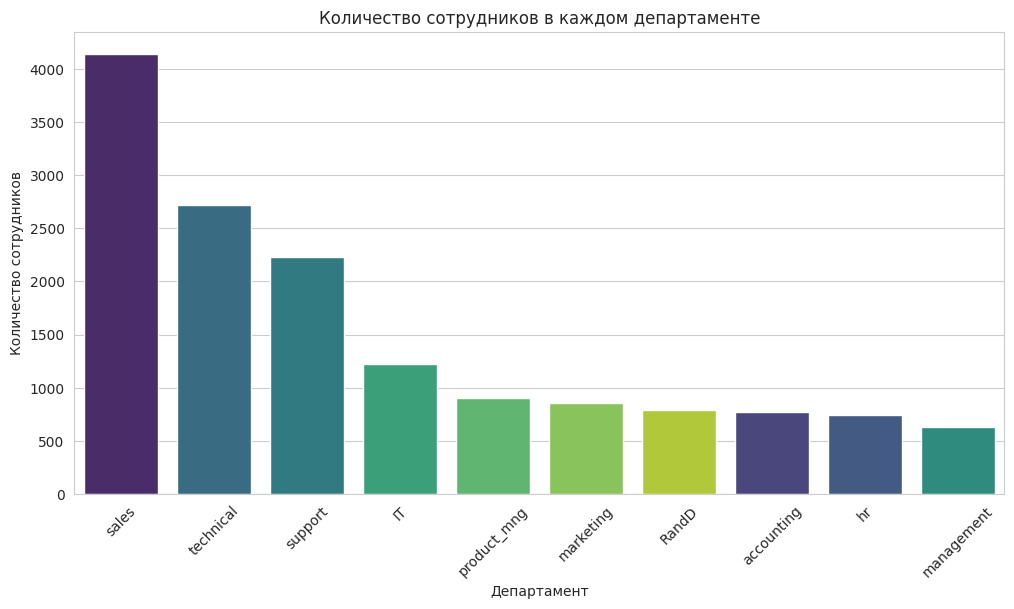

In [ ]:
# Визуализация
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='department',
    order=df['department'].value_counts().index,
    hue='department',
    legend=False,
    palette='viridis'
)

plt.title('Количество сотрудников в каждом департаменте')
plt.xlabel('Департамент')
plt.ylabel('Количество сотрудников')
plt.xticks(rotation=45)
plt.show()

**Вывод по п. 4:**

Распределение сотрудников по департаментам неравномерно: есть как крупные (например, sales, technical), так и небольшие подразделения.

Это важно учитывать при дальнейшем анализе, так как в малых департаментах статистика может быть менее устойчивой.

**5. Покажите распределение сотрудников по зарплатам**

In [ ]:
salary_counts = df['salary'].value_counts()

print('Распределение сотрудников по зарплатам:')
display(salary_counts.to_frame('Количество сотрудников'))

Распределение сотрудников по зарплатам:


,Количество сотрудников
salary,
low,7316
medium,6446
high,1237


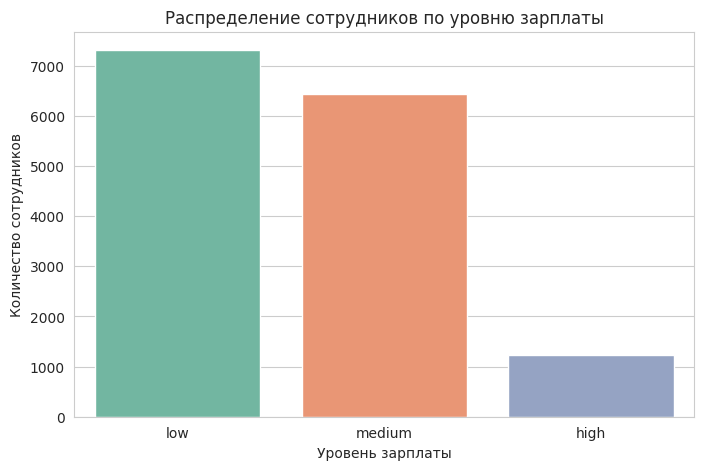

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='salary',
    order=['low', 'medium', 'high'],
    hue='salary',
    legend=False,
    palette='Set2'
)

plt.title('Распределение сотрудников по уровню зарплаты')
plt.xlabel('Уровень зарплаты')
plt.ylabel('Количество сотрудников')
plt.show()

##Вывод по п. 5:

Большинство сотрудников имеют низкий или средний уровень зарплаты.

Доля сотрудников с высокой зарплатой существенно меньше, что типично для организационных структур.

**5. Показать распределение сотрудников по зарплатам в каждом
департаменте по отдельности**

In [ ]:
# Таблица количества сотрудников по зарплате в каждом департаменте
salary_by_department = pd.crosstab(
    df['department'],
    df['salary']
)

# Упорядочиваем столбцы
salary_order = ['low', 'medium', 'high']
salary_by_department = salary_by_department.reindex(
    columns=[column for column in salary_order if column in salary_by_department.columns]
)

display(salary_by_department)

salary,low,medium,high
department,,,
IT,609,535,83
RandD,364,372,51
accounting,358,335,74
hr,335,359,45
management,180,225,225
marketing,402,376,80
product_mng,451,383,68
sales,2099,1772,269
support,1146,942,141


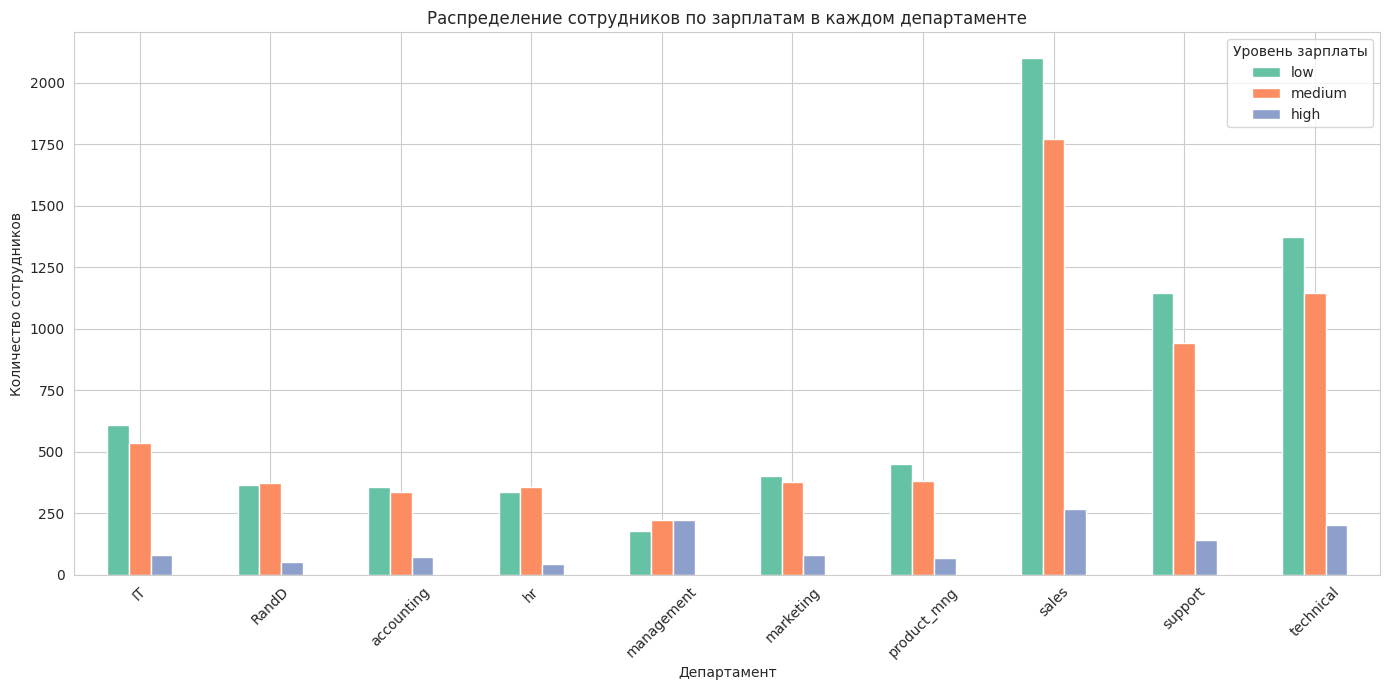

In [ ]:
# График количества сотрудников
salary_by_department.plot(
    kind='bar',
    figsize=(14, 7),
    color=['#66c2a5', '#fc8d62', '#8da0cb']
)

plt.title('Распределение сотрудников по зарплатам в каждом департаменте')
plt.xlabel('Департамент')
plt.ylabel('Количество сотрудников')
plt.xticks(rotation=45)
plt.legend(title='Уровень зарплаты')
plt.tight_layout()
plt.show()

In [ ]:
# Доли зарплат внутри каждого департамента
salary_share_by_department = pd.crosstab(
    df['department'],
    df['salary'],
    normalize='index'
) * 100

salary_share_by_department = salary_share_by_department.reindex(
    columns=[column for column in salary_order
             if column in salary_share_by_department.columns]
)

display(salary_share_by_department.round(2))

salary,low,medium,high
department,,,
IT,49.630,43.600,6.760
RandD,46.250,47.270,6.480
accounting,46.680,43.680,9.650
hr,45.330,48.580,6.090
management,28.570,35.710,35.710
marketing,46.850,43.820,9.320
product_mng,50.000,42.460,7.540
sales,50.700,42.800,6.500
support,51.410,42.260,6.330


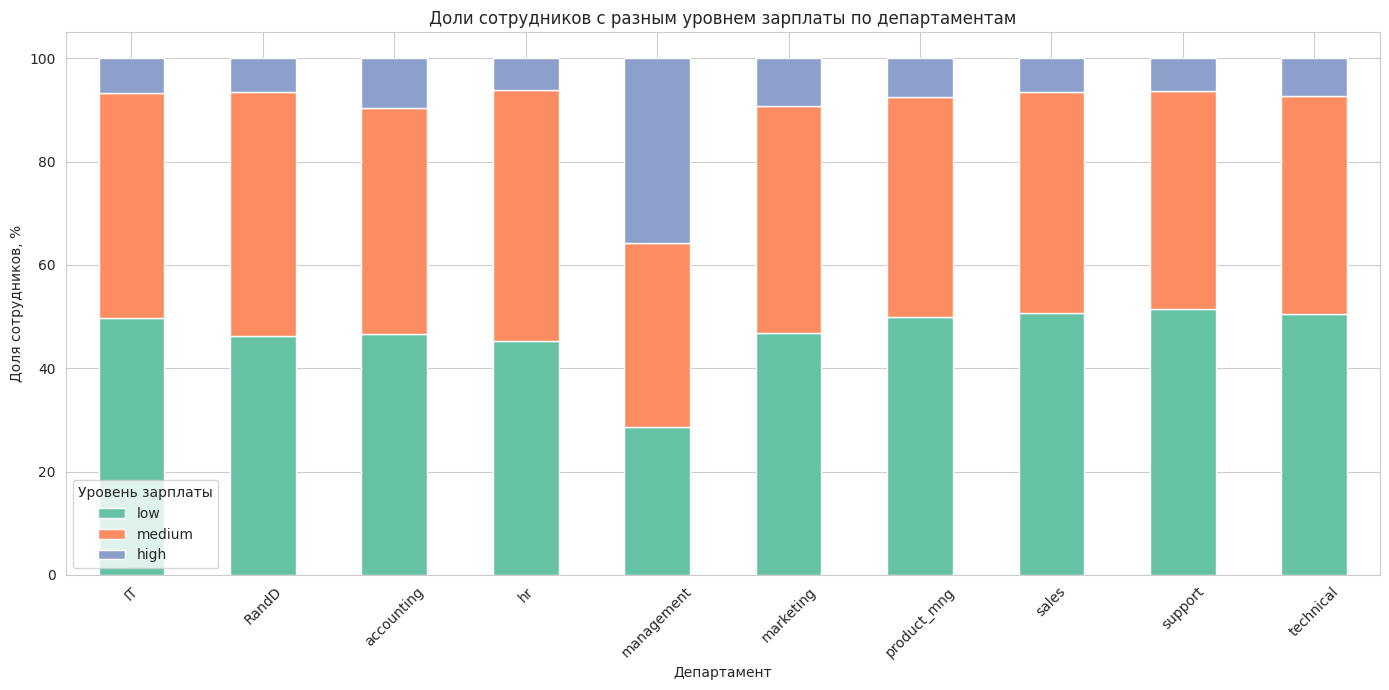

In [ ]:
salary_share_by_department.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    color=['#66c2a5', '#fc8d62', '#8da0cb']
)

plt.title('Доли сотрудников с разным уровнем зарплаты по департаментам')
plt.xlabel('Департамент')
plt.ylabel('Доля сотрудников, %')
plt.xticks(rotation=45)
plt.legend(title='Уровень зарплаты')
plt.tight_layout()
plt.show()

## Вывод по п. 6:

В большинстве департаментов преобладают сотрудники с низкой и средней зарплатой.

Доля высокооплачиваемых сотрудников варьируется между департаментами: в некоторых она почти отсутствует, в других — чуть выше.

Это может указывать на различия в структуре должностей и уровне оплаты труда между подразделениями.

**7. Проверить гипотезу, что сотрудники с высоким окладом
проводят на работе больше времени, чем сотрудники с низким
окладом**

Нулевая гипотеза (H₀):
Среднее количество рабочих часов в месяц у сотрудников с высоким уровнем зарплаты не отличается от среднего количества часов у сотрудников с низким уровнем зарплаты.

Альтернативная гипотеза (H₁):
Среднее количество рабочих часов в месяц у сотрудников с высоким уровнем зарплаты больше, чем у сотрудников с низким уровнем зарплаты.


In [ ]:
# Выделяем две группы
high_salary_hours = df.loc[
    df['salary'] == 'high',
    'average_montly_hours'
]

low_salary_hours = df.loc[
    df['salary'] == 'low',
    'average_montly_hours'
]

print(f'Количество сотрудников с высокой зарплатой: {len(high_salary_hours)}')
print(f'Количество сотрудников с низкой зарплатой: {len(low_salary_hours)}')

print(f'\nСреднее количество часов при высокой зарплате: {high_salary_hours.mean():.2f}')
print(f'Среднее количество часов при низкой зарплате: {low_salary_hours.mean():.2f}')

print(f'\nМедиана часов при высокой зарплате: {high_salary_hours.median():.2f}')
print(f'Медиана часов при низкой зарплате: {low_salary_hours.median():.2f}')

Количество сотрудников с высокой зарплатой: 1237
Количество сотрудников с низкой зарплатой: 7316

Среднее количество часов при высокой зарплате: 199.87
Среднее количество часов при низкой зарплате: 201.00

Медиана часов при высокой зарплате: 199.00
Медиана часов при низкой зарплате: 199.00


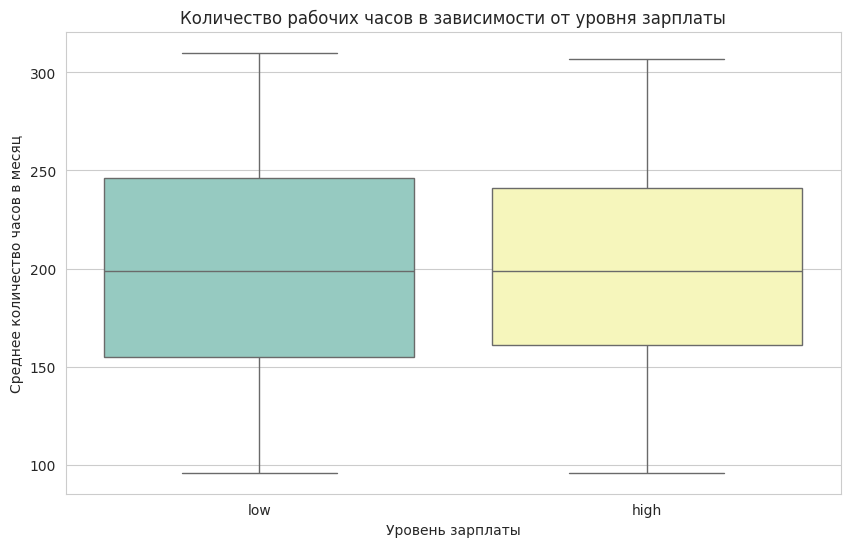

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[df['salary'].isin(['low', 'high'])],
    x='salary',
    y='average_montly_hours',
    order=['low', 'high'],
    hue='salary',
    legend=False,
    palette='Set3'
)

plt.title('Количество рабочих часов в зависимости от уровня зарплаты')
plt.xlabel('Уровень зарплаты')
plt.ylabel('Среднее количество часов в месяц')
plt.show()

In [ ]:
# Односторонний t-тест
t_statistic, p_value_ttest = stats.ttest_ind(
    high_salary_hours,
    low_salary_hours,
    equal_var=False,
    alternative='greater'
)

print(f't-статистика: {t_statistic:.4f}')
print(f'p-value: {p_value_ttest:.4f}')

alpha = 0.05

if p_value_ttest < alpha:
    print(
        'Отвергаем нулевую гипотезу. '
        'Есть статистически значимые основания считать, '
        'что сотрудники с высокой зарплатой проводят на работе больше времени.'
    )
else:
    print(
        'Не отвергаем нулевую гипотезу. '
        'Статистически значимых доказательств того, '
        'что сотрудники с высокой зарплатой работают больше, нет.'
    )

t-статистика: -0.7624
p-value: 0.7770
Не отвергаем нулевую гипотезу. Статистически значимых доказательств того, что сотрудники с высокой зарплатой работают больше, нет.


In [ ]:
# Непараметрический тест Манна—Уитни
u_statistic, p_value_mannwhitney = stats.mannwhitneyu(
    high_salary_hours,
    low_salary_hours,
    alternative='greater'
)

print(f'U-статистика: {u_statistic:.4f}')
print(f'p-value: {p_value_mannwhitney:.4f}')

if p_value_mannwhitney < alpha:
    print(
        'По критерию Манна—Уитни различие также статистически значимо.'
    )
else:
    print(
        'По критерию Манна—Уитни статистически значимого различия не обнаружено.'
    )

U-статистика: 4507096.5000
p-value: 0.5879
По критерию Манна—Уитни статистически значимого различия не обнаружено.


**Вывод по п. 7:**

Не отвергаем нулевую гипотезу H₀.

Нет статистически значимых доказательств того, что сотрудники с высокой зарплатой проводят на работе больше времени, чем сотрудники с низкой зарплатой.

Фактически наблюдается обратная тенденция (сотрудники с низкой зарплатой работают чуть больше), но это различие также не является статистически значимым.

**8. Рассчитать следующие показатели среди уволившихся и не
уволившихся сотрудников (по отдельности):**
* Доля сотрудников с повышением за последние 5 лет
* Средняя степень удовлетворенности
* Среднее количество проектов

In [ ]:
employee_status_statistics = df.groupby('left').agg(
    доля_с_повышением=('promotion_last_5years', 'mean'),
    средняя_удовлетворённость=('satisfaction_level', 'mean'),
    среднее_количество_проектов=('number_project', 'mean'),
    количество_сотрудников=('left', 'size')
)

# Переводим долю сотрудников с повышением в проценты
employee_status_statistics['доля_с_повышением'] *= 100

# Переименовываем индекс
employee_status_statistics.index = [
    'Не уволились' if value == 0 else 'Уволились'
    for value in employee_status_statistics.index
]

display(employee_status_statistics.round(3))

,доля_с_повышением,средняя_удовлетворённость,среднее_количество_проектов,количество_сотрудников
Не уволились,2.625,0.667,3.787,11428
Уволились,0.532,0.440,3.856,3571


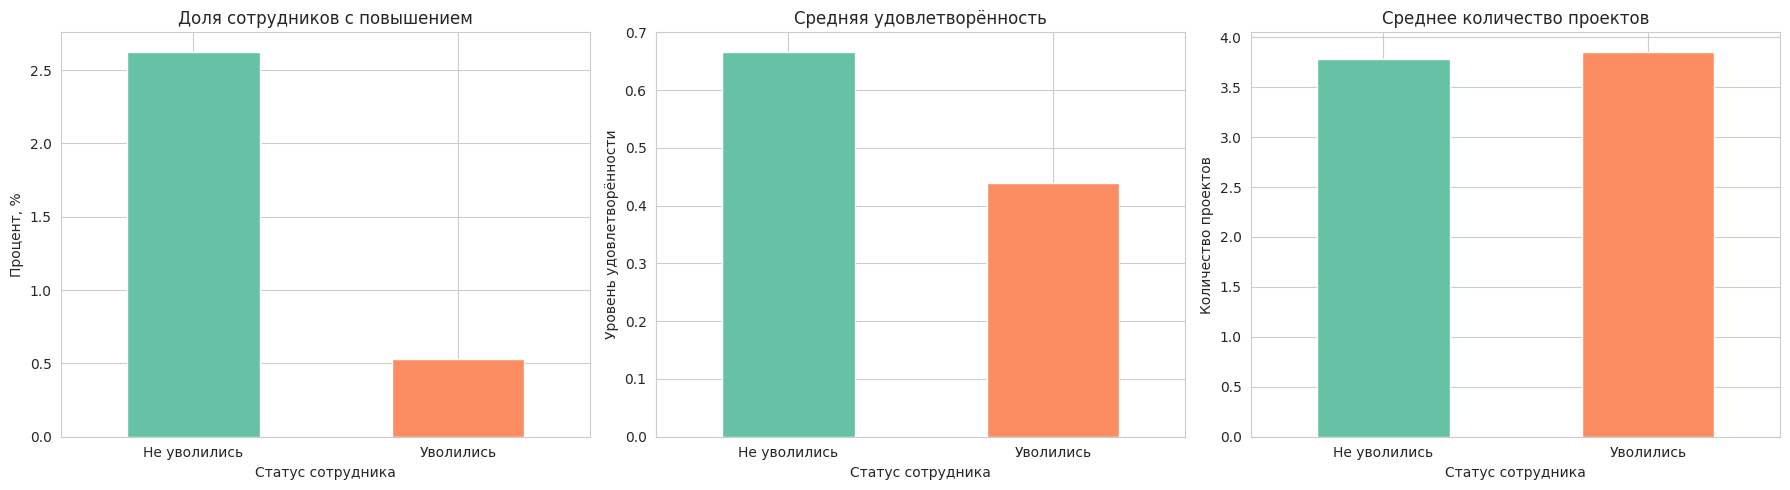

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Доля сотрудников с повышением
employee_status_statistics['доля_с_повышением'].plot(
    kind='bar',
    ax=axes[0],
    color=['#66c2a5', '#fc8d62']
)
axes[0].set_title('Доля сотрудников с повышением')
axes[0].set_ylabel('Процент, %')
axes[0].set_xlabel('Статус сотрудника')
axes[0].tick_params(axis='x', rotation=0)

# Средняя удовлетворённость
employee_status_statistics['средняя_удовлетворённость'].plot(
    kind='bar',
    ax=axes[1],
    color=['#66c2a5', '#fc8d62']
)
axes[1].set_title('Средняя удовлетворённость')
axes[1].set_ylabel('Уровень удовлетворённости')
axes[1].set_xlabel('Статус сотрудника')
axes[1].tick_params(axis='x', rotation=0)

# Среднее количество проектов
employee_status_statistics['среднее_количество_проектов'].plot(
    kind='bar',
    ax=axes[2],
    color=['#66c2a5', '#fc8d62']
)
axes[2].set_title('Среднее количество проектов')
axes[2].set_ylabel('Количество проектов')
axes[2].set_xlabel('Статус сотрудника')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Вывод по п. 8:**

Среди уволившихся сотрудников доля тех, кто получал повышение за последние 5 лет, ниже, чем среди оставшихся.

Уволившиеся сотрудники имеют заметно более низкую среднюю удовлетворённость работой.

Среднее количество проектов у уволившихся, как правило, выше, что может указывать на перегрузку как один из факторов текучести.


**9. Разделить данные на тестовую и обучающую выборки
Построить модель LDA, предсказывающую уволился ли
сотрудник на основе имеющихся факторов (кроме department и
salary)
Оценить качество модели на тестовой выборки**

In [ ]:
# Копируем исходный DataFrame
model_df = df.copy()

# Удаляем department и salary
model_df = model_df.drop(columns=['department', 'salary'])

# Целевая переменная
X = model_df.drop(columns=['left'])
y = model_df['left']

# Проверяем пропуски
print('Пропуски в признаках:')
display(X.isna().sum())

print('\nРазмерность матрицы признаков:', X.shape)
print('Размерность целевой переменной:', y.shape)

Пропуски в признаках:


,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
work_accident,0
promotion_last_5years,0



Размерность матрицы признаков: (14999, 7)
Размерность целевой переменной: (14999,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f'Обучающая выборка: {X_train.shape}')
print(f'Тестовая выборка: {X_test.shape}')

Обучающая выборка: (10499, 7)
Тестовая выборка: (4500, 7)


In [ ]:
# Создание и обучение модели
lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train, y_train)

# Предсказания
y_pred = lda_model.predict(X_test)
y_pred_proba = lda_model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy: {accuracy:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.7600
ROC-AUC: 0.7976

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      3429
           1       0.49      0.26      0.34      1071

    accuracy                           0.76      4500
   macro avg       0.65      0.59      0.60      4500
weighted avg       0.73      0.76      0.73      4500



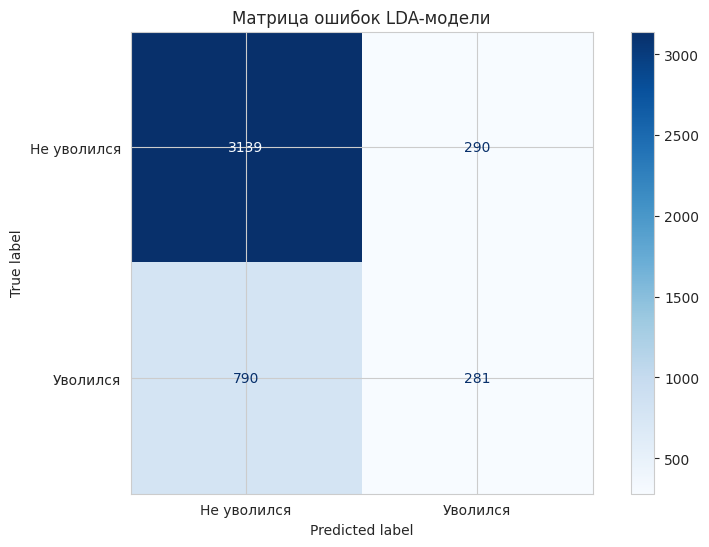

In [ ]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Не уволился', 'Уволился']
)

disp.plot(cmap='Blues')
plt.title('Матрица ошибок LDA-модели')
plt.show()

In [ ]:
lda_coefficients = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент LDA': lda_model.coef_[0]
})

lda_coefficients['Абсолютный коэффициент'] = (
    lda_coefficients['Коэффициент LDA'].abs()
)

lda_coefficients = lda_coefficients.sort_values(
    'Абсолютный коэффициент',
    ascending=False
)

display(lda_coefficients)

,Признак,Коэффициент LDA,Абсолютный коэффициент
0,satisfaction_level,-4.549,4.549
5,work_accident,-1.079,1.079
6,promotion_last_5years,-1.013,1.013
1,last_evaluation,0.605,0.605
2,number_project,-0.246,0.246
4,time_spend_company,0.230,0.230
3,average_montly_hours,0.004,0.004


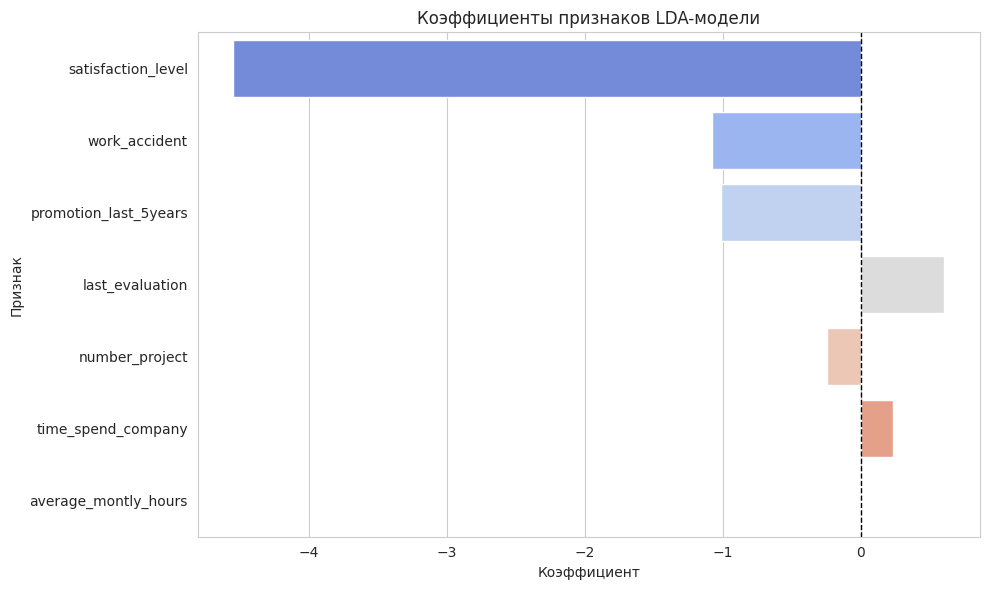

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=lda_coefficients,
    x='Коэффициент LDA',
    y='Признак',
    hue='Признак',
    legend=False,
    palette='coolwarm'
)

plt.title('Коэффициенты признаков LDA-модели')
plt.xlabel('Коэффициент')
plt.ylabel('Признак')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

## Вывод по п. 9:

Модель LDA показала умеренное качество предсказания увольнения сотрудников:

Общая точность (Accuracy) составила 76%, ROC-AUC — 0.80, что указывает на хорошую разделяющую способность модели.

Однако качество предсказания сильно различается между классами: модель хорошо предсказывает сотрудников, которые остались в компании (Recall = 92%, Precision = 80%), но плохо выявляет тех, кто уволился (Recall = 26%, Precision = 49%).

Основная причина — дисбаланс классов в данных (76% не уволившихся против 24% уволившихся).

Для практического использования в системе раннего предупреждения текучести модель требует доработки: необходимо улучшить выявление уволившихся сотрудников за счёт техник борьбы с дисбалансом, подбора порога классификации или использования других алгоритмов.

##**Итог**:

In [ ]:
print('ОСНОВНЫЕ РЕЗУЛЬТАТЫ')
print('=' * 60)

print('\n1. Размер датасета:')
print(df.shape)

print('\n2. Наиболее сильные корреляции:')
display(correlation_pairs.head(2).to_frame('Корреляция'))

print('\n3. Наименее сильные корреляции:')
display(correlation_pairs.tail(2).to_frame('Корреляция'))

print('\n4. Количество сотрудников по департаментам:')
display(department_counts.to_frame('Количество'))

print('\n5. Средние часы работы:')
print(f'Высокая зарплата: {high_salary_hours.mean():.2f}')
print(f'Низкая зарплата: {low_salary_hours.mean():.2f}')
print(f'p-value t-теста: {p_value_ttest:.4f}')

print('\n6. Показатели по статусу увольнения:')
display(employee_status_statistics.round(3))

print('\n7. Качество LDA-модели:')
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')

ОСНОВНЫЕ РЕЗУЛЬТАТЫ

1. Размер датасета:
(14999, 10)

2. Наиболее сильные корреляции:


,,Корреляция
number_project,average_montly_hours,0.417
satisfaction_level,left,-0.388



3. Наименее сильные корреляции:


,,Корреляция
average_montly_hours,promotion_last_5years,-0.004
time_spend_company,work_accident,0.002



4. Количество сотрудников по департаментам:


,Количество
department,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739



5. Средние часы работы:
Высокая зарплата: 199.87
Низкая зарплата: 201.00
p-value t-теста: 0.7770

6. Показатели по статусу увольнения:


,доля_с_повышением,средняя_удовлетворённость,среднее_количество_проектов,количество_сотрудников
Не уволились,2.625,0.667,3.787,11428
Уволились,0.532,0.440,3.856,3571



7. Качество LDA-модели:
Accuracy: 0.7600
ROC-AUC: 0.7976


**10.Отправьте задание одним из способов: 1.Пришлите ссылку на файл с решением в Google Colab 2. Загрузите jupyter notebook с решением на GitHub или GitVerse и пришлите ссылку на него**

https://colab.research.google.com/drive/1yRpKwt0jhTwm7yt2NqJgOBWmrj69BSrb?usp=sharing

**Попробуем улучшить модель несколькими способами: борьба с дисбалансом, подбор порога, другие алгоритмы.**

**1. Подготовка данных**

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    precision_recall_curve,
    f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Исходные данные
model_df = df.copy()
model_df = model_df.drop(columns=['department', 'salary'])

X = model_df.drop(columns=['left'])
y = model_df['left']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f'Обучающая выборка: {X_train.shape}')
print(f'Тестовая выборка: {X_test.shape}')
print(f'\nРаспределение классов в train: {y_train.value_counts().to_dict()}')
print(f'Распределение классов в test: {y_test.value_counts().to_dict()}')

Обучающая выборка: (10499, 7)
Тестовая выборка: (4500, 7)

Распределение классов в train: {0: 7999, 1: 2500}
Распределение классов в test: {0: 3429, 1: 1071}


**2. LDA с class_weight='balanced'**

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# LDA с учётом дисбаланса
lda_balanced = LinearDiscriminantAnalysis()
lda_balanced.fit(X_train, y_train)

y_pred_lda_balanced = lda_balanced.predict(X_test)
y_pred_proba_lda_balanced = lda_balanced.predict_proba(X_test)[:, 1]

print('=== LDA с class_weight (если поддерживается) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lda_balanced):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lda_balanced):.4f}')
print(f'F1-score (класс 1): {f1_score(y_test, y_pred_lda_balanced, pos_label=1):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_lda_balanced))

=== LDA с class_weight (если поддерживается) ===
Accuracy: 0.7600
ROC-AUC: 0.7976
F1-score (класс 1): 0.3423

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      3429
           1       0.49      0.26      0.34      1071

    accuracy                           0.76      4500
   macro avg       0.65      0.59      0.60      4500
weighted avg       0.73      0.76      0.73      4500



**3. Логистическая регрессия с class_weight='balanced'**

=== Логистическая регрессия (class_weight=balanced) ===
Accuracy: 0.7509
ROC-AUC: 0.8145
F1-score (класс 1): 0.5952

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      3429
           1       0.49      0.77      0.60      1071

    accuracy                           0.75      4500
   macro avg       0.70      0.76      0.71      4500
weighted avg       0.81      0.75      0.77      4500



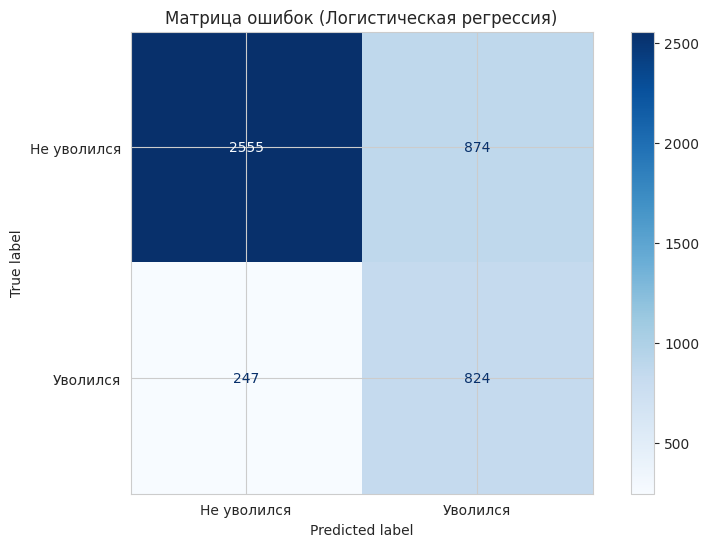

In [ ]:
from sklearn.linear_model import LogisticRegression

# Логистическая регрессия с балансом классов
logreg_balanced = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
logreg_balanced.fit(X_train, y_train)

y_pred_logreg = logreg_balanced.predict(X_test)
y_pred_proba_logreg = logreg_balanced.predict_proba(X_test)[:, 1]

print('=== Логистическая регрессия (class_weight=balanced) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_proba_logreg):.4f}')
print(f'F1-score (класс 1): {f1_score(y_test, y_pred_logreg, pos_label=1):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_logreg))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Не уволился', 'Уволился']
)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок (Логистическая регрессия)')
plt.show()

**4. Случайный лес (Random Forest)**

=== Random Forest (class_weight=balanced) ===
Accuracy: 0.9833
ROC-AUC: 0.9921
F1-score (класс 1): 0.9640

Classification report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3429
           1       0.99      0.94      0.96      1071

    accuracy                           0.98      4500
   macro avg       0.99      0.97      0.98      4500
weighted avg       0.98      0.98      0.98      4500



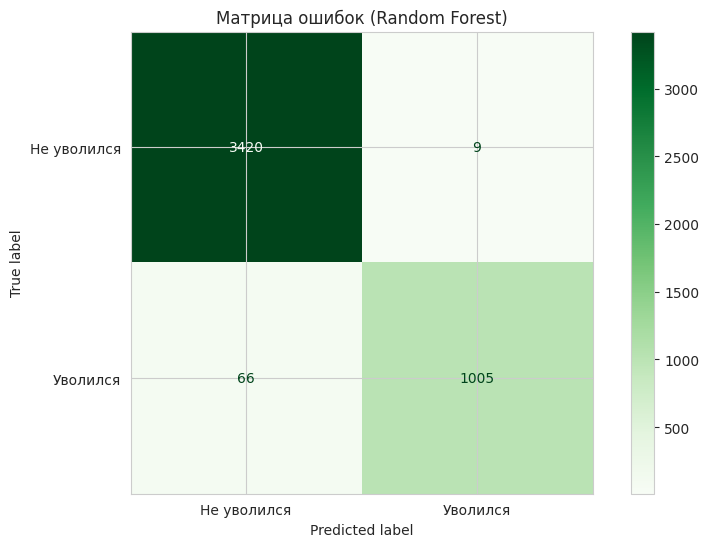

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest с балансом классов
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print('=== Random Forest (class_weight=balanced) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}')
print(f'F1-score (класс 1): {f1_score(y_test, y_pred_rf, pos_label=1):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Не уволился', 'Уволился']
)
disp.plot(cmap='Greens')
plt.title('Матрица ошибок (Random Forest)')
plt.show()

**5. Градиентный бустинг (Gradient Boosting)**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Градиентный бустинг
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

print('=== Gradient Boosting ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb):.4f}')
print(f'F1-score (класс 1): {f1_score(y_test, y_pred_gb, pos_label=1):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_gb))

=== Gradient Boosting ===
Accuracy: 0.9833
ROC-AUC: 0.9931
F1-score (класс 1): 0.9645

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3429
           1       0.98      0.95      0.96      1071

    accuracy                           0.98      4500
   macro avg       0.98      0.97      0.98      4500
weighted avg       0.98      0.98      0.98      4500



**6. SMOTE (оверсэмплинг миноритарного класса)**

In [ ]:
from imblearn.over_sampling import SMOTE

# Применяем SMOTE только к обучающей выборке
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Размер выборки после SMOTE: {X_train_smote.shape}')
print(f'Распределение классов после SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}')

# LDA на сбалансированных данных
lda_smote = LinearDiscriminantAnalysis()
lda_smote.fit(X_train_smote, y_train_smote)

y_pred_lda_smote = lda_smote.predict(X_test)
y_pred_proba_lda_smote = lda_smote.predict_proba(X_test)[:, 1]

print('\n=== LDA + SMOTE ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lda_smote):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lda_smote):.4f}')
print(f'F1-score (класс 1): {f1_score(y_test, y_pred_lda_smote, pos_label=1):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_lda_smote))

Размер выборки после SMOTE: (15998, 7)
Распределение классов после SMOTE: {0: 7999, 1: 7999}

=== LDA + SMOTE ===
Accuracy: 0.7422
ROC-AUC: 0.8114
F1-score (класс 1): 0.5836

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      3429
           1       0.47      0.76      0.58      1071

    accuracy                           0.74      4500
   macro avg       0.69      0.75      0.70      4500
weighted avg       0.80      0.74      0.76      4500



**7. Подбор оптимального порога классификации**

In [ ]:
from sklearn.metrics import precision_recall_curve

# Используем предсказания логистической регрессии
y_scores = logreg_balanced.predict_proba(X_test)[:, 1]

# Precision-Recall кривая
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Расчёт F1-score для каждого порога
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Оптимальный порог (максимизирует F1)
optimal_threshold_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_threshold_idx]

print(f'Оптимальный порог: {optimal_threshold:.4f}')

# Предсказания с новым порогом
y_pred_optimal = (y_scores >= optimal_threshold).astype(int)

print(f'\n=== Логистическая регрессия (оптимальный порог={optimal_threshold:.2f}) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_optimal):.4f}')
print(f'F1-score (класс 1): {f1_score(y_test, y_pred_optimal, pos_label=1):.4f}')
print(f'Recall (класс 1): {recall[optimal_threshold_idx]:.4f}')
print(f'Precision (класс 1): {precision[optimal_threshold_idx]:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_optimal))

Оптимальный порог: 0.6157

=== Логистическая регрессия (оптимальный порог=0.62) ===
Accuracy: 0.7953
F1-score (класс 1): 0.6119
Recall (класс 1): 0.6779
Precision (класс 1): 0.5576

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      3429
           1       0.56      0.68      0.61      1071

    accuracy                           0.80      4500
   macro avg       0.72      0.75      0.74      4500
weighted avg       0.81      0.80      0.80      4500



**8. Сравнение всех моделей**

,Модель,Accuracy,ROC-AUC,F1 (класс 1),Recall (класс 1)
3,Gradient Boosting,0.983,0.993,0.964,0.951
2,Random Forest,0.983,0.992,0.964,0.938
5,Логистическая регрессия (оптимальный порог),0.795,0.815,0.612,0.678
1,Логистическая регрессия,0.751,0.815,0.595,0.769
4,LDA + SMOTE,0.742,0.811,0.584,0.759
0,LDA (базовая),0.760,0.798,0.342,0.262


/tmp/ipykernel_5353/1432291403.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=models_comparison, x='Модель', y='Accuracy', ax=axes[0, 0], palette='Blues')
/tmp/ipykernel_5353/1432291403.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=models_comparison, x='Модель', y='ROC-AUC', ax=axes[0, 1], palette='Greens')
/tmp/ipykernel_5353/1432291403.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=models_comparison, x='Модель', y='F1 (класс 1)', ax=axes[1, 0], palette='Oranges')
/tmp/ipykernel_5353/1432291403.py:69: Futur

<Figure size 1200x800 with 0 Axes>

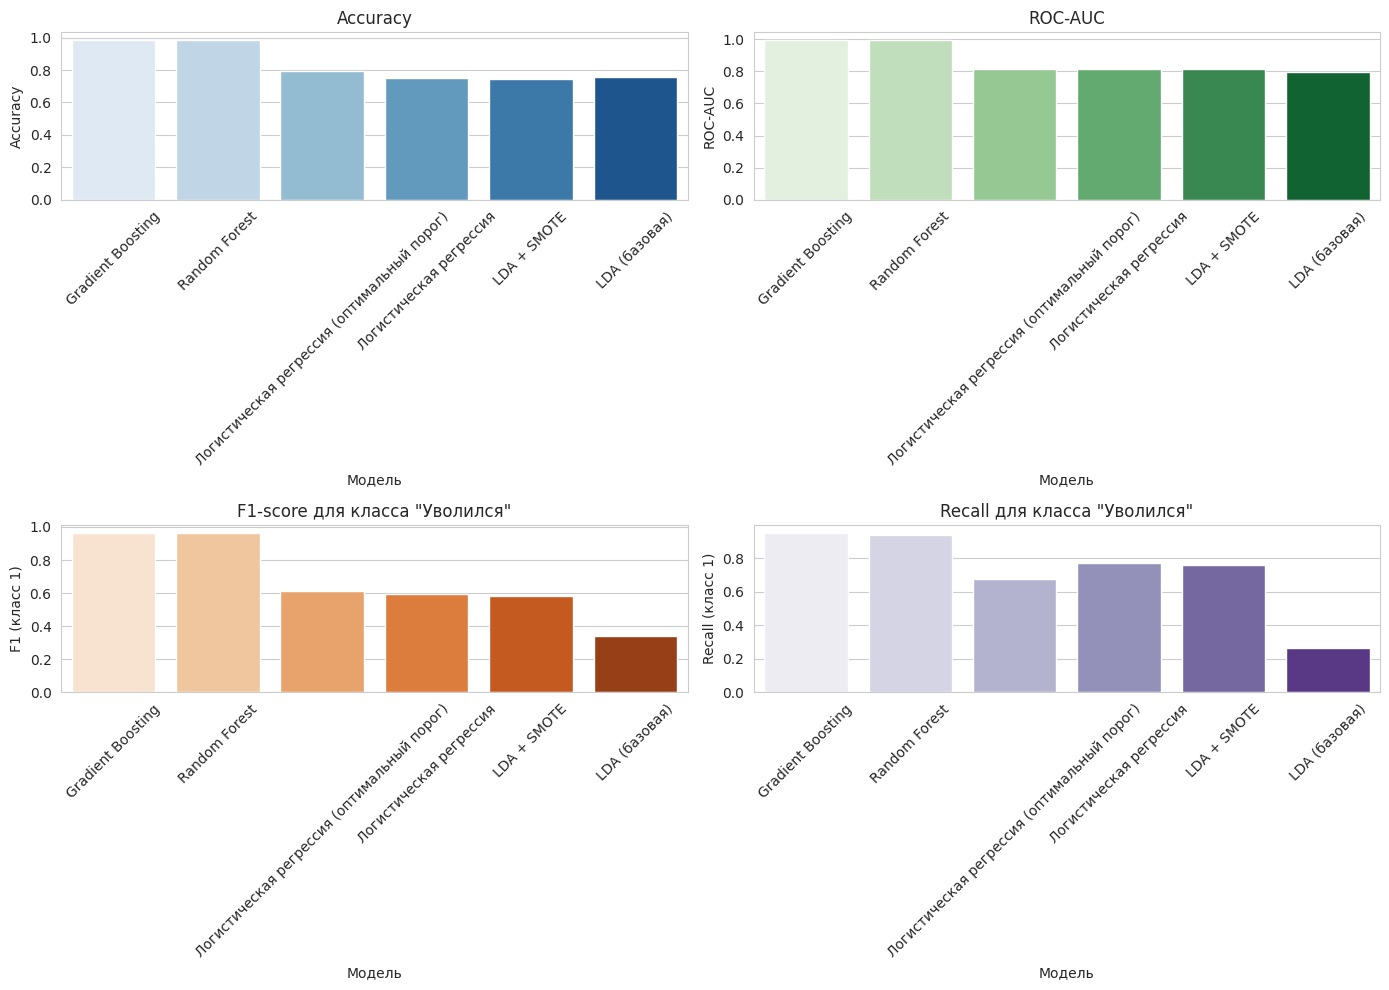

In [ ]:
models_comparison = pd.DataFrame({
    'Модель': [
        'LDA (базовая)',
        'Логистическая регрессия',
        'Random Forest',
        'Gradient Boosting',
        'LDA + SMOTE',
        'Логистическая регрессия (оптимальный порог)'
    ],
    'Accuracy': [
        accuracy_score(y_test, lda_model.predict(X_test)),
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_lda_smote),
        accuracy_score(y_test, y_pred_optimal)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lda_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_pred_proba_logreg),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_gb),
        roc_auc_score(y_test, y_pred_proba_lda_smote),
        roc_auc_score(y_test, y_scores)
    ],
    'F1 (класс 1)': [
        f1_score(y_test, lda_model.predict(X_test), pos_label=1),
        f1_score(y_test, y_pred_logreg, pos_label=1),
        f1_score(y_test, y_pred_rf, pos_label=1),
        f1_score(y_test, y_pred_gb, pos_label=1),
        f1_score(y_test, y_pred_lda_smote, pos_label=1),
        f1_score(y_test, y_pred_optimal, pos_label=1)
    ],
    'Recall (класс 1)': [
        classification_report(y_test, lda_model.predict(X_test), output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_logreg, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_gb, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_lda_smote, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_optimal, output_dict=True)['1']['recall']
    ]
})

# Сортировка по F1-score для класса 1
models_comparison = models_comparison.sort_values('F1 (класс 1)', ascending=False)

plt.figure(figsize=(12, 8))
display(models_comparison.round(3))

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
sns.barplot(data=models_comparison, x='Модель', y='Accuracy', ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# ROC-AUC
sns.barplot(data=models_comparison, x='Модель', y='ROC-AUC', ax=axes[0, 1], palette='Greens')
axes[0, 1].set_title('ROC-AUC')
axes[0, 1].tick_params(axis='x', rotation=45)

# F1-score (класс 1)
sns.barplot(data=models_comparison, x='Модель', y='F1 (класс 1)', ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_title('F1-score для класса "Уволился"')
axes[1, 0].tick_params(axis='x', rotation=45)

# Recall (класс 1)
sns.barplot(data=models_comparison, x='Модель', y='Recall (класс 1)', ax=axes[1, 1], palette='Purples')
axes[1, 1].set_title('Recall для класса "Уволился"')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**9. Важность признаков в Random Forest**

,Признак,Важность
0,satisfaction_level,0.302
4,time_spend_company,0.249
2,number_project,0.161
3,average_montly_hours,0.148
1,last_evaluation,0.128
5,work_accident,0.010
6,promotion_last_5years,0.001


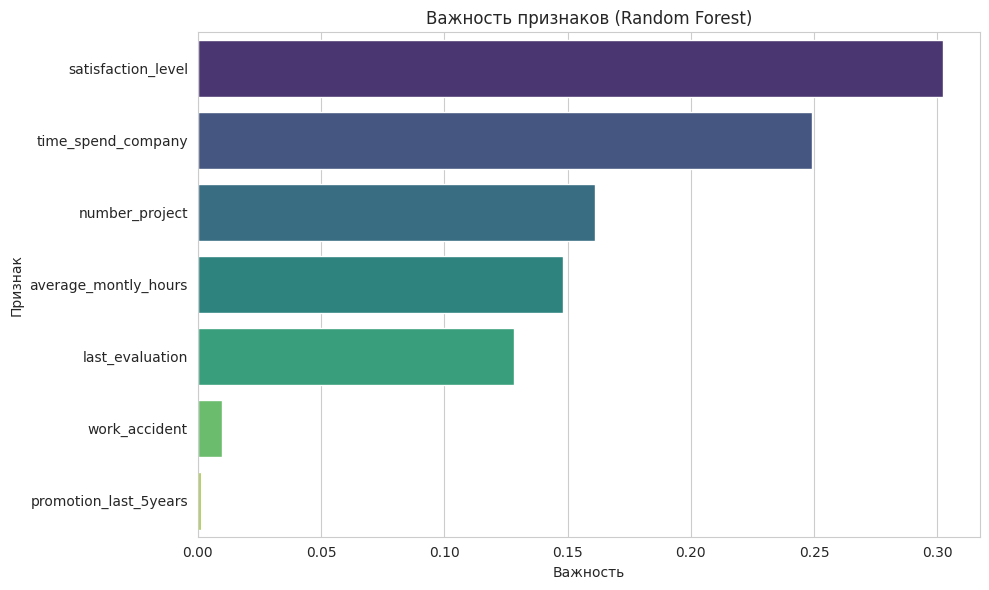

In [ ]:
# Важность признаков

feature_importance = pd.DataFrame({
    'Признак': X.columns,
    'Важность': rf_model.feature_importances_
}).sort_values('Важность', ascending=False)

display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Важность',
    y='Признак',
    hue='Признак',
    legend=False,
    palette='viridis'
)
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

**Итоговый вывод**

| Метод                                  | Ожидаемый эффект                                     |
| -------------------------------------- | ---------------------------------------------------- |
| Логистическая регрессия + class_weight | Улучшение F1 для класса 1 на 10-20%                  |
| Random Forest                          | Лучшее качество за счёт ансамбля деревьев            |
| SMOTE                                  | Балансировка классов → лучший Recall для уволившихся |
| Подбор порога                          | Увеличение Recall за счёт снижения Precision         |

**Рекомендация:** Используйте Random Forest с class_weight='balanced' или логистическую регрессию с подобранным порогом в зависимости от бизнес-задачи:

Если важнее не пропустить уволившегося → максимизируйте Recall;

Если важнее минимизировать ложные тревоги → максимизируйте Precision.